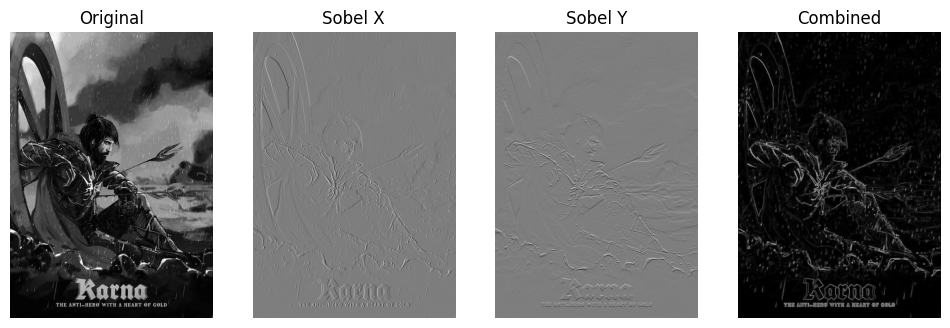

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
image = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Computer Vision/karna.jpg", 0)

# Sobel X
sobel_x = cv2.Sobel(
    image,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)

# Sobel Y
sobel_y = cv2.Sobel(
    image,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

# Gradient magnitude
sobel = np.sqrt(
    sobel_x**2 +
    sobel_y**2
)

# sobel = cv2.Sobel(image,cv2.CV_64F,1,1,ksize=3)
# We are not using this because it is a mixed derivative i.e. change in intensity
# wrt x and y simultaneously and it is not equal to change in (x+y)

# Display
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(sobel_x, cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(sobel_y, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(sobel, cmap='gray')
plt.title("Combined")
plt.axis("off")

plt.show()

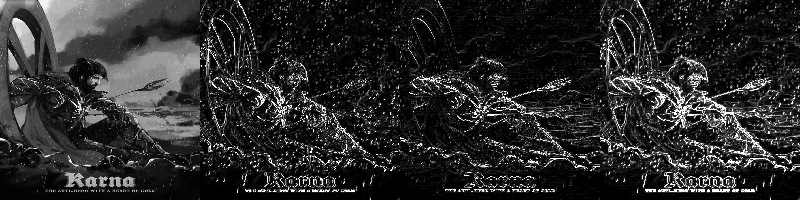

In [25]:
from google.colab.patches import cv2_imshow

# 1. Resize each image so they fit comfortably side-by-side
small_size = (200, 200) # Width, Height for each individual image
img_resized = cv2.resize(image, small_size)

# Normalizing the 64F float images to 8-bit unsigned integers so they display correctly with hstack
sobel_x_resized = cv2.convertScaleAbs(cv2.resize(sobel_x, small_size))
sobel_y_resized = cv2.convertScaleAbs(cv2.resize(sobel_y, small_size))
sobel_resized = cv2.convertScaleAbs(cv2.resize(sobel, small_size))

# 2. Stack them horizontally into a single image row
side_by_side = np.hstack((img_resized, sobel_x_resized, sobel_y_resized, sobel_resized))

# 3. Display the single combined row
cv2_imshow(side_by_side)